# Gold Layer — Exploratory Data Analysis (EDA)

This notebook loads the three gold-layer views exported as CSV files from the
`exports/gold/` folder and performs an end-to-end exploratory analysis:

| # | Section |
|---|---------|
| 1 | Setup & imports |
| 2 | Load data |
| 3 | Data quality inspection |
| 4 | Sales trends over time |
| 5 | Product & category analysis |
| 6 | Customer demographics |
| 7 | Key summary metrics |

> **Before running:** make sure the `sql_medallion` conda environment is active and
> that `export_gold_views.py` has been executed so the CSVs exist.

## 1 — Setup & Imports

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Notebook display settings ─────────────────────────────────
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

# ── Path to exported CSVs ─────────────────────────────────────
# Resolves to  <repo_root>/exports/gold/  regardless of where
# JupyterLab is launched from.
EXPORTS = Path("..") / "exports" / "gold"

print("Environment ready ✓")

Environment ready ✓


## 2 — Load Data

In [2]:
# Parse date columns on load so we can use them directly for time series.
customers = pd.read_csv(
    EXPORTS / "dim_customers.csv",
    parse_dates=["birthdate", "create_date"],
)

products = pd.read_csv(EXPORTS / "dim_products.csv", parse_dates=["start_date"])

sales = pd.read_csv(
    EXPORTS / "fact_sales.csv",
    parse_dates=["order_date", "shipping_date", "due_date"],
)

print(f"dim_customers : {customers.shape[0]:>6,} rows × {customers.shape[1]} cols")
print(f"dim_products  : {products.shape[0]:>6,} rows × {products.shape[1]} cols")
print(f"fact_sales    : {sales.shape[0]:>6,} rows × {sales.shape[1]} cols")

dim_customers : 18,484 rows × 10 cols
dim_products  :    295 rows × 11 cols
fact_sales    : 60,398 rows × 9 cols


## 3 — Data Quality Inspection

In [3]:
def quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Return a tidy per-column summary: dtype, # nulls, % nulls, # unique values."""
    report = pd.DataFrame({
        "dtype":    df.dtypes.astype(str),
        "nulls":    df.isna().sum(),
        "null_%":   (df.isna().mean() * 100).round(2),
        "unique":   df.nunique(),
    })
    print(f"\n{'─'*50}")
    print(f"  {name}  ({df.shape[0]:,} rows × {df.shape[1]} cols)")
    print(f"{'─'*50}")
    return report

display(quality_report(customers,  "dim_customers"))
display(quality_report(products,   "dim_products"))
display(quality_report(sales,      "fact_sales"))


──────────────────────────────────────────────────
  dim_customers  (18,484 rows × 10 cols)
──────────────────────────────────────────────────


,dtype,nulls,null_%,unique
customer_key,int64,0,0.00,18484
customer_id,int64,0,0.00,18484
customer_number,str,0,0.00,18484
first_name,str,0,0.00,670
last_name,str,0,0.00,375
country,str,0,0.00,10
marital_status,str,0,0.00,2
gender,str,4569,24.72,2
birthdate,datetime64[us],17,0.09,6135
create_date,datetime64[us],0,0.00,114



──────────────────────────────────────────────────
  dim_products  (295 rows × 11 cols)
──────────────────────────────────────────────────


,dtype,nulls,null_%,unique
product_key,int64,0,0.00,295
product_id,int64,0,0.00,295
product_number,str,0,0.00,295
product_name,str,0,0.00,295
category_id,str,0,0.00,37
category,str,7,2.37,4
subcategory,str,7,2.37,36
maintenance,str,7,2.37,3
cost,float64,0,0.00,90
product_line,str,17,5.76,4



──────────────────────────────────────────────────
  fact_sales  (60,398 rows × 9 cols)
──────────────────────────────────────────────────


,dtype,nulls,null_%,unique
order_number,str,0,0.00,27659
product_key,int64,0,0.00,130
customer_key,int64,0,0.00,18484
order_date,datetime64[us],19,0.03,1124
shipping_date,datetime64[us],0,0.00,1124
due_date,datetime64[us],0,0.00,1124
sales_amount,float64,0,0.00,45
quantity,int64,0,0.00,6
sls_price,float64,0,0.00,41


In [4]:
# Quick peek at the first rows of each table
print("── dim_customers ──")
display(customers.head(3))

print("── dim_products ──")
display(products.head(3))

print("── fact_sales ──")
display(sales.head(3))

── dim_customers ──


,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date
0,1,11000,AW00011000,Jon,Yang,Australia\r,Married,Male,1971-10-06,2025-10-06
1,2,11001,AW00011001,Eugene,Huang,Australia\r,Single,Male,1976-05-10,2025-10-06
2,3,11002,AW00011002,Ruben,Torres,Australia\r,Married,Male,1971-02-09,2025-10-06


── dim_products ──


,product_key,product_id,product_number,product_name,category_id,category,subcategory,maintenance,cost,product_line,start_date
0,1,210,FR-R92B-58,HL Road Frame - Black- 58,CO_RF,Components,Road Frames,Yes\r,0.00,Road,2003-07-01
1,2,211,FR-R92R-58,HL Road Frame - Red- 58,CO_RF,Components,Road Frames,Yes\r,0.00,Road,2003-07-01
2,3,348,BK-M82B-38,Mountain-100 Black- 38,BI_MB,Bikes,Mountain Bikes,Yes\r,"1,898.00",Mountain,2011-07-01


── fact_sales ──


,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,sls_price
0,SO43697,20,10769,2010-12-29,2011-01-05,2011-01-10,"3,578.00",1,"3,578.00"
1,SO43698,9,17390,2010-12-29,2011-01-05,2011-01-10,"3,400.00",1,"3,400.00"
2,SO43699,9,14864,2010-12-29,2011-01-05,2011-01-10,"3,400.00",1,"3,400.00"


## 4 — Sales Trends Over Time

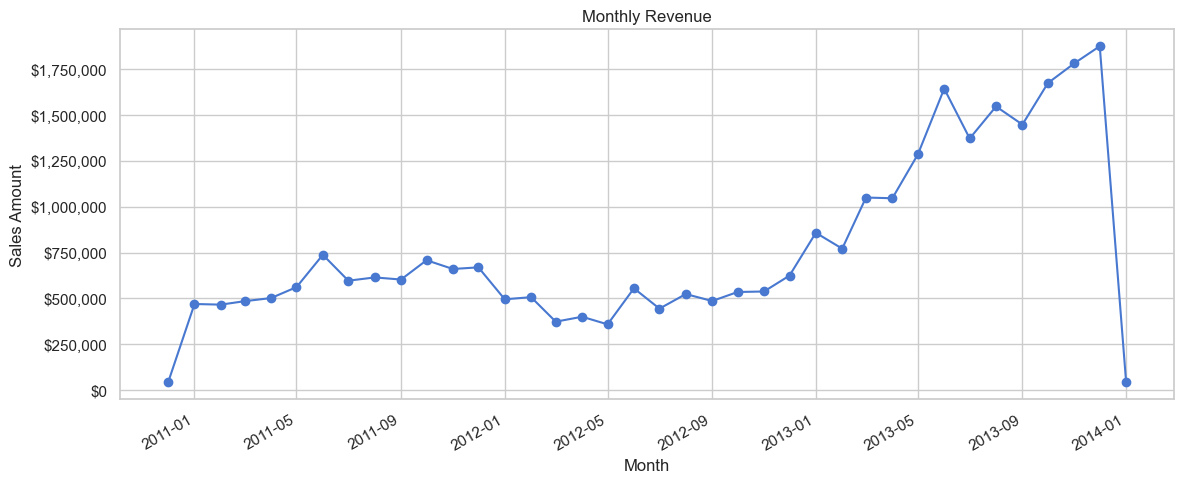

In [5]:
# ── Monthly revenue trend ─────────────────────────────────────
monthly = (
    sales
    .assign(month=sales["order_date"].dt.to_period("M"))
    .groupby("month", as_index=False)["sales_amount"]
    .sum()
)
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(monthly["month_dt"], monthly["sales_amount"], marker="o", linewidth=1.5)
ax.set_title("Monthly Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Sales Amount")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

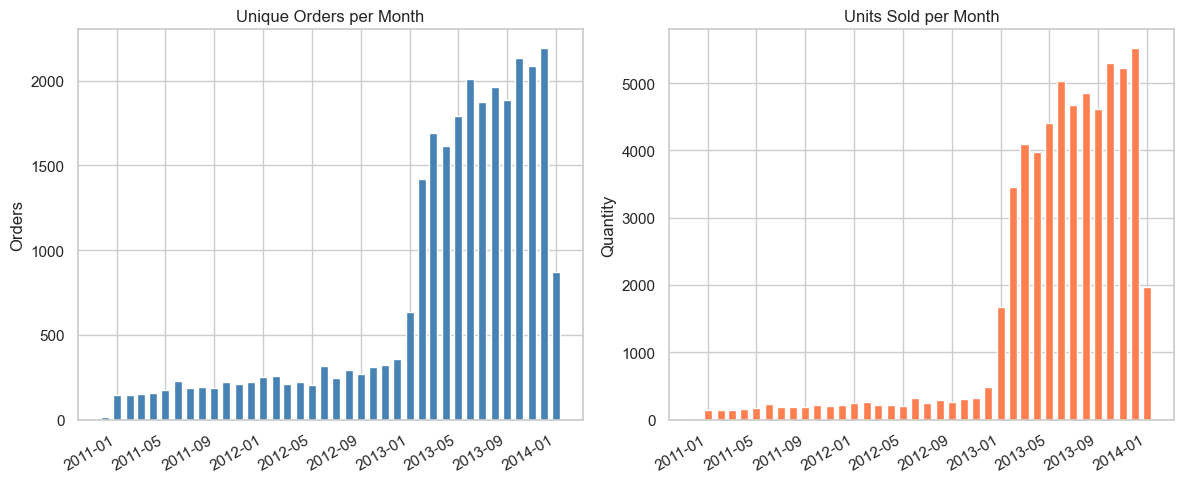

In [6]:
# ── Orders and quantity sold per month (secondary analysis) ───
monthly_qty = (
    sales
    .assign(month=sales["order_date"].dt.to_period("M"))
    .groupby("month", as_index=False)
    .agg(orders=("order_number", "nunique"), units_sold=("quantity", "sum"))
)
monthly_qty["month_dt"] = monthly_qty["month"].dt.to_timestamp()

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.bar(monthly_qty["month_dt"], monthly_qty["orders"], width=20, color="steelblue")
ax1.set_title("Unique Orders per Month")
ax1.set_ylabel("Orders")
fig.autofmt_xdate()

ax2.bar(monthly_qty["month_dt"], monthly_qty["units_sold"], width=20, color="coral")
ax2.set_title("Units Sold per Month")
ax2.set_ylabel("Quantity")
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## 5 — Product & Category Analysis

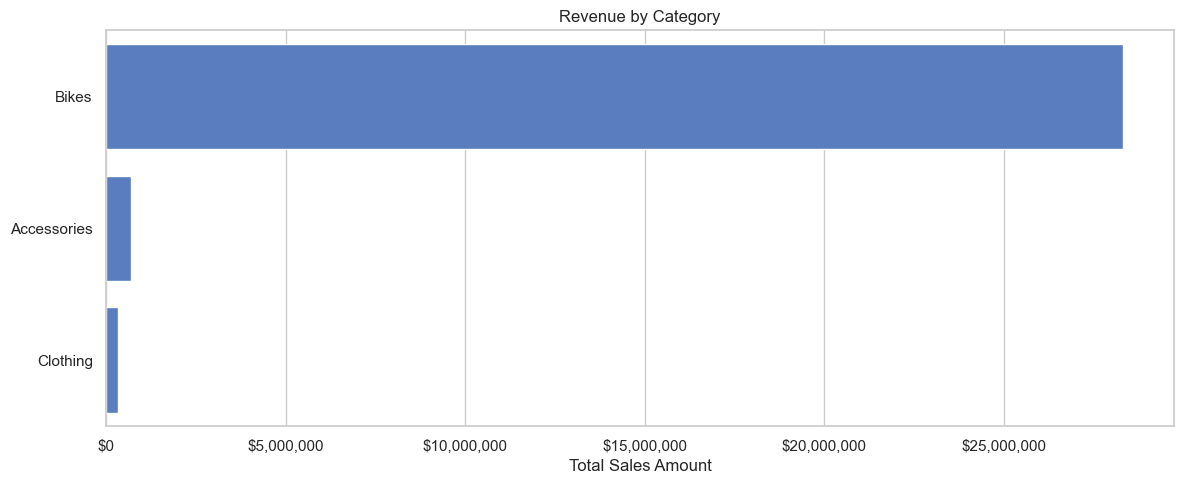

In [7]:
# ── Revenue by product category ───────────────────────────────
# Join sales → products to get the category name.
sales_prod = sales.merge(
    products[["product_key", "product_name", "category", "subcategory", "cost"]],
    on="product_key",
    how="left",
)

cat_revenue = (
    sales_prod
    .groupby("category", as_index=False)["sales_amount"]
    .sum()
    .sort_values("sales_amount", ascending=False)
)

fig, ax = plt.subplots()
sns.barplot(data=cat_revenue, x="sales_amount", y="category", ax=ax, orient="h")
ax.set_title("Revenue by Category")
ax.set_xlabel("Total Sales Amount")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

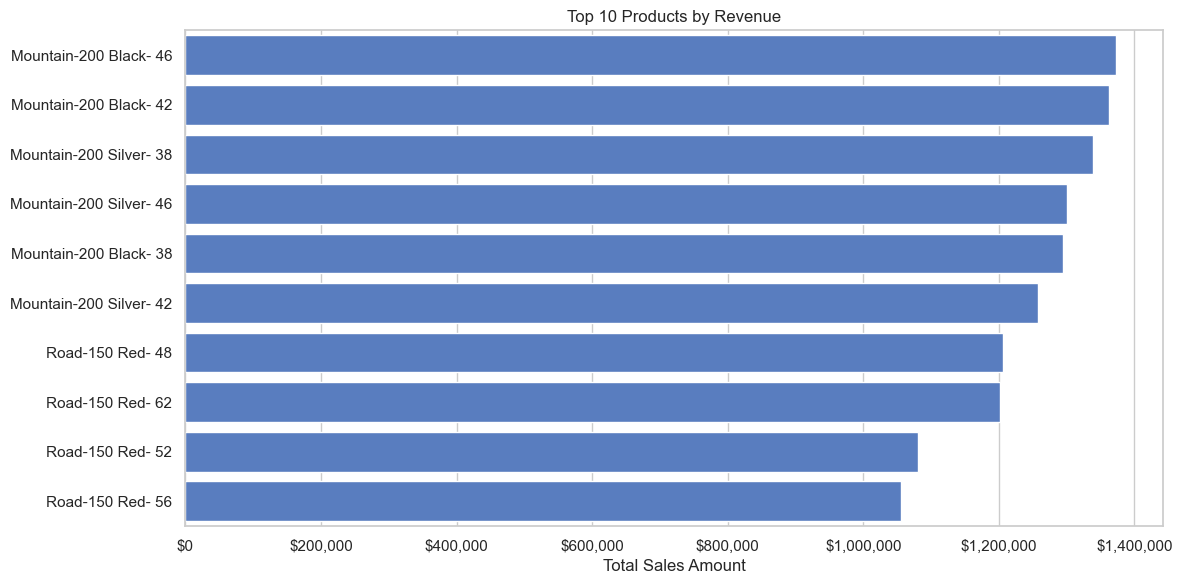

In [8]:
# ── Top 10 products by revenue ────────────────────────────────
top_products = (
    sales_prod
    .groupby("product_name", as_index=False)["sales_amount"]
    .sum()
    .nlargest(10, "sales_amount")
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_products, x="sales_amount", y="product_name", ax=ax, orient="h")
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Total Sales Amount")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## 6 — Customer Demographics

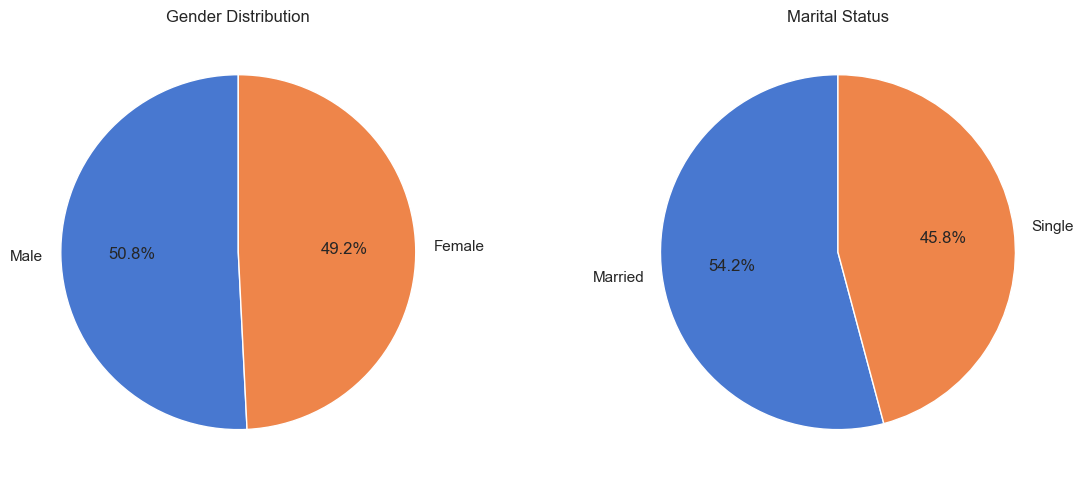

In [9]:
# ── Gender & marital status distribution ──────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2)

gender_counts = customers["gender"].value_counts()
ax1.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
ax1.set_title("Gender Distribution")

marital_counts = customers["marital_status"].value_counts()
ax2.pie(marital_counts, labels=marital_counts.index, autopct="%1.1f%%", startangle=90)
ax2.set_title("Marital Status")

plt.tight_layout()
plt.show()

ValueError: Could not interpret value `count` for `x`. An entry with this name does not appear in `data`.

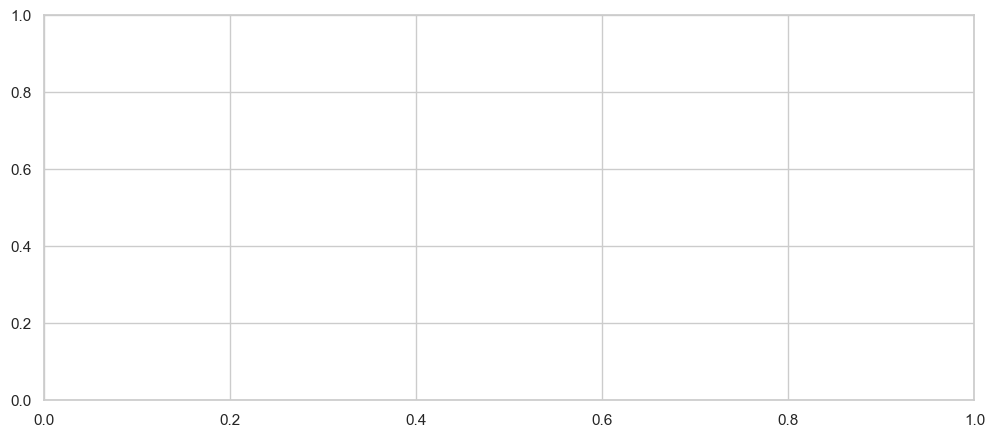

In [10]:
# ── Customer count by country ─────────────────────────────────
country_counts = (
    customers["country"]
    .value_counts()
    .reset_index()
    .rename(columns={"count": "customers"})
)

fig, ax = plt.subplots()
sns.barplot(data=country_counts, x="count", y="country", ax=ax, orient="h")
ax.set_title("Customers by Country")
ax.set_xlabel("Number of Customers")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

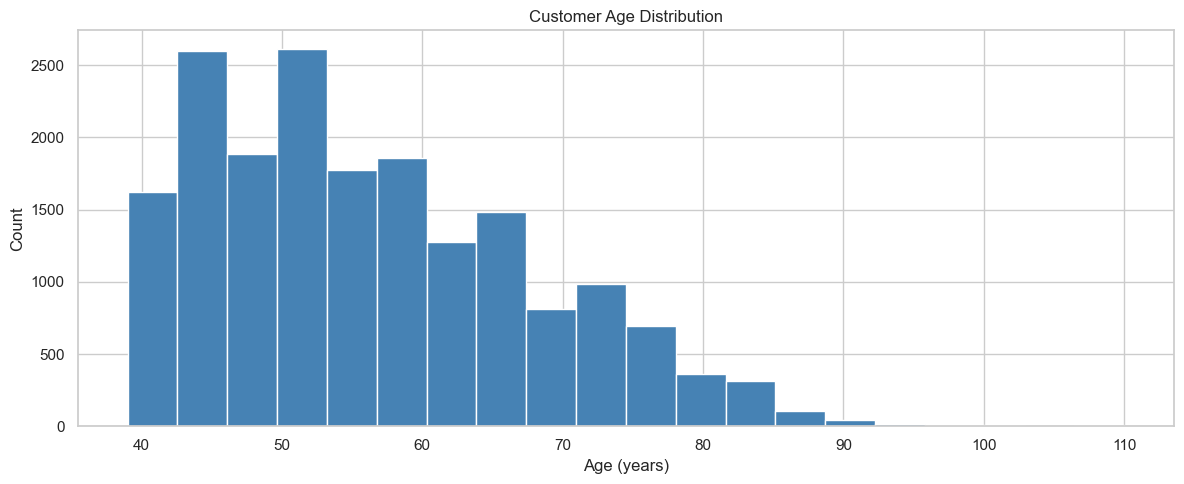

count   18,467.00
mean        56.45
std         11.54
min         39.00
25%         47.00
50%         54.00
75%         64.00
max        110.00
Name: age_stats, dtype: float64


In [11]:
# ── Customer age distribution (derived from birthdate) ────────
customers_with_age = customers.dropna(subset=["birthdate"]).copy()
customers_with_age["age"] = (
    pd.Timestamp("today") - customers_with_age["birthdate"]
).dt.days // 365

fig, ax = plt.subplots()
ax.hist(customers_with_age["age"], bins=20, color="steelblue", edgecolor="white")
ax.set_title("Customer Age Distribution")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(customers_with_age["age"].describe().rename("age_stats"))

## 7 — Key Summary Metrics

In [12]:
# ── High-level KPIs ───────────────────────────────────────────
total_revenue   = sales["sales_amount"].sum()
total_orders    = sales["order_number"].nunique()
avg_order_value = total_revenue / total_orders if total_orders else 0
total_customers = customers["customer_id"].nunique()
total_products  = products["product_id"].nunique()
date_range      = f"{sales['order_date'].min().date()}  →  {sales['order_date'].max().date()}"

kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Avg Order Value",
        "Unique Customers",
        "Active Products",
        "Date Range",
    ],
    "Value": [
        f"${total_revenue:,.2f}",
        f"{total_orders:,}",
        f"${avg_order_value:,.2f}",
        f"{total_customers:,}",
        f"{total_products:,}",
        date_range,
    ],
})

kpis = kpis.set_index("Metric")
display(kpis.style.set_caption("Gold Layer — Summary KPIs"))

,Value
Metric,
Total Revenue,"$29,356,250.00"
Total Orders,"27,659"
Avg Order Value,"$1,061.36"
Unique Customers,"18,484"
Active Products,295
Date Range,2010-12-29 → 2014-01-28


## Actionable EDA Playbook (Gold Layer)

This section is a practical, repeatable EDA workflow over the exported Gold CSVs:
- `dim_customers.csv`
- `dim_products.csv`
- `fact_sales.csv`
- `pricing_kpi_monthly.csv`

Execution order:
1. Load and standardize data types.
2. Validate quality and relational consistency.
3. Explore distributions and key business metrics.
4. Detect anomalies and produce an action log.
5. (Optional) Run ad hoc SQL from notebook for deep dives.

Readability note:
Each cell includes concise comments so this notebook is approachable for mixed skill levels.

In [13]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Consistent visual defaults for quick EDA readability.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

PROJECT_ROOT = Path("..").resolve()
GOLD_DIR = PROJECT_ROOT / "exports" / "gold"

print(f"Project root: {PROJECT_ROOT}")
print(f"Gold path exists: {GOLD_DIR.exists()} -> {GOLD_DIR}")

Project root: C:\Users\hecto\OneDrive\Documentos\VSCode\sql_medallion_data_warehouse
Gold path exists: True -> C:\Users\hecto\OneDrive\Documentos\VSCode\sql_medallion_data_warehouse\exports\gold


In [14]:
# Load all Gold exports.
dim_customers = pd.read_csv(GOLD_DIR / "dim_customers.csv")
dim_products = pd.read_csv(GOLD_DIR / "dim_products.csv")
fact_sales = pd.read_csv(GOLD_DIR / "fact_sales.csv")
pricing_kpi_monthly = pd.read_csv(GOLD_DIR / "pricing_kpi_monthly.csv")

# Best-effort date parsing for common date-like columns.
def coerce_dates(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in df.columns:
        name = col.lower()
        if any(token in name for token in ["date", "month", "year", "dt"]):
            try:
                df[col] = pd.to_datetime(df[col], errors="ignore")
            except Exception:
                pass
    return df

# Standardize tables.
dim_customers = coerce_dates(dim_customers)
dim_products = coerce_dates(dim_products)
fact_sales = coerce_dates(fact_sales)
pricing_kpi_monthly = coerce_dates(pricing_kpi_monthly)

print("Loaded shapes:")
for name, df in {
    "dim_customers": dim_customers,
    "dim_products": dim_products,
    "fact_sales": fact_sales,
    "pricing_kpi_monthly": pricing_kpi_monthly,
}.items():
    print(f"- {name}: {df.shape}")

Loaded shapes:
- dim_customers: (18484, 10)
- dim_products: (295, 11)
- fact_sales: (60398, 9)
- pricing_kpi_monthly: (9971, 14)


In [15]:
# Profile each dataset in a compact way.
def profile_table(name: str, df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "table": [name],
        "rows": [len(df)],
        "cols": [df.shape[1]],
        "null_cells": [int(df.isna().sum().sum())],
        "duplicate_rows": [int(df.duplicated().sum())],
    })

overview = pd.concat([
    profile_table("dim_customers", dim_customers),
    profile_table("dim_products", dim_products),
    profile_table("fact_sales", fact_sales),
    profile_table("pricing_kpi_monthly", pricing_kpi_monthly),
], ignore_index=True)

overview

,table,rows,cols,null_cells,duplicate_rows
0,dim_customers,18484,10,4586,0
1,dim_products,295,11,38,0
2,fact_sales,60398,9,19,0
3,pricing_kpi_monthly,9971,14,0,0


In [16]:
# Referential integrity check helper.
def candidate_keys(df: pd.DataFrame):
    return [c for c in df.columns if c.lower() in {"customer_key", "product_key", "date_key", "customer_id", "product_id", "order_id"}]

print("Candidate keys by table:")
for table_name, df in {
    "dim_customers": dim_customers,
    "dim_products": dim_products,
    "fact_sales": fact_sales,
}.items():
    print(f"- {table_name}: {candidate_keys(df)}")

# If keys exist, report orphan rates for fact -> dimensions.
if "customer_key" in fact_sales.columns and "customer_key" in dim_customers.columns:
    orphan_customers = ~fact_sales["customer_key"].isin(dim_customers["customer_key"])
    print(f"Orphan customer_key rows in fact_sales: {int(orphan_customers.sum())}")

if "product_key" in fact_sales.columns and "product_key" in dim_products.columns:
    orphan_products = ~fact_sales["product_key"].isin(dim_products["product_key"])
    print(f"Orphan product_key rows in fact_sales: {int(orphan_products.sum())}")

Candidate keys by table:
- dim_customers: ['customer_key', 'customer_id']
- dim_products: ['product_key', 'product_id']
- fact_sales: ['product_key', 'customer_key']
Orphan customer_key rows in fact_sales: 0
Orphan product_key rows in fact_sales: 0


Numeric measure columns in fact_sales (3): ['sales_amount', 'quantity', 'sls_price']


,count,mean,std,min,25%,50%,75%,max
sales_amount,"60,398.00",486.05,928.45,2.00,8.00,30.00,540.00,"3,578.00"
quantity,"60,398.00",1.00,0.04,1.00,1.00,1.00,1.00,10.00
sls_price,"60,398.00",486.04,928.45,2.00,8.00,30.00,540.00,"3,578.00"


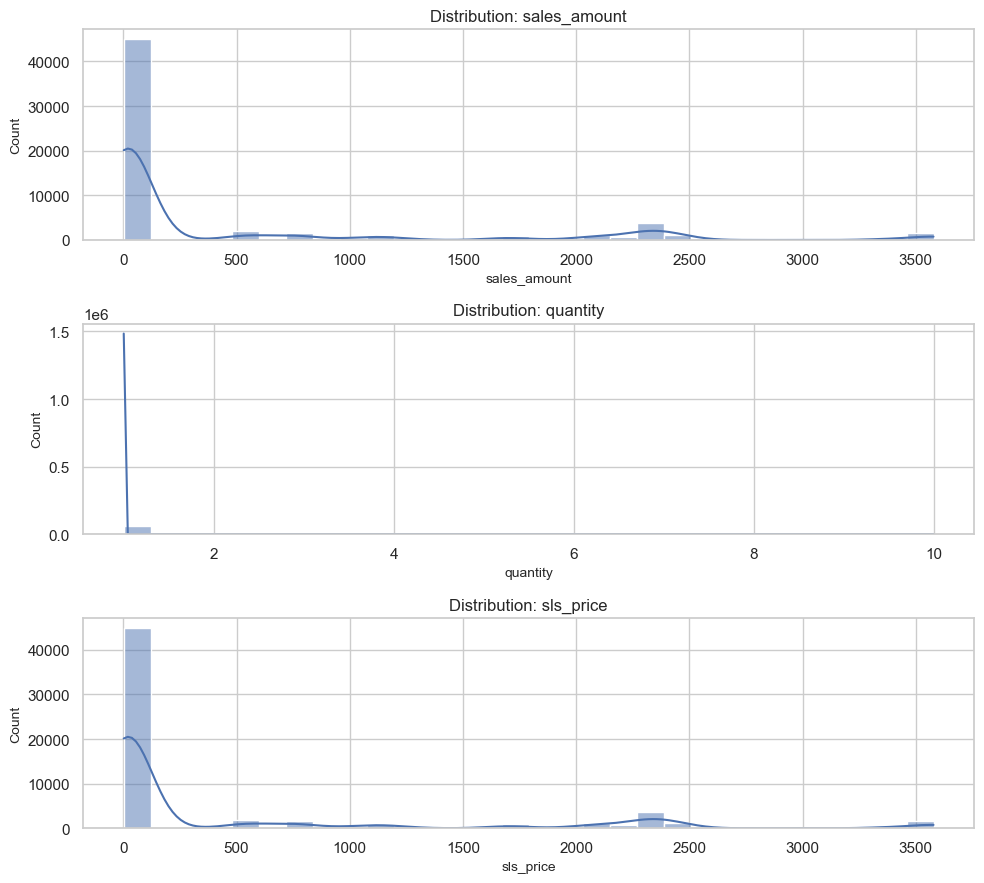

In [19]:
# Numeric distributions: quick univariate scan for fact table.
# Exclude identifier-like fields because they are not business measures.
all_num_cols = fact_sales.select_dtypes(include=["number"]).columns.tolist()
num_cols = [
    c for c in all_num_cols
    if not (
        c.lower().endswith("_key")
        or c.lower().endswith("_id")
        or c.lower() in {"order_number", "order_id"}
    )
]

print(f"Numeric measure columns in fact_sales ({len(num_cols)}): {num_cols}")

if num_cols:
    display(fact_sales[num_cols].describe().T)

    top_n = min(6, len(num_cols))
    fig, axes = plt.subplots(top_n, 1, figsize=(10, 3 * top_n))
    if top_n == 1:
        axes = [axes]

    for ax, col in zip(axes, num_cols[:top_n]):
        sns.histplot(fact_sales[col].dropna(), bins=30, kde=True, ax=ax)
        ax.set_title(f"Distribution: {col}")

    plt.tight_layout()
    plt.show()
else:
    print("No numeric measure columns found in fact_sales.")

In [ ]:
# Monthly KPI trend from pricing_kpi_monthly (or fallback from fact_sales).
def guess_time_col(df: pd.DataFrame):
    for c in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[c]):
            return c
    for c in df.columns:
        if any(token in c.lower() for token in ["month", "date", "year"]):
            return c
    return None

def guess_value_cols(df: pd.DataFrame):
    nums = df.select_dtypes(include=["number"]).columns.tolist()
    priority = [c for c in nums if any(k in c.lower() for k in ["sales", "revenue", "amount", "margin", "profit", "price", "quantity"])]
    return priority[:3] if priority else nums[:3]

kpi_df = pricing_kpi_monthly.copy()
time_col = guess_time_col(kpi_df)
value_cols = guess_value_cols(kpi_df)

if time_col and value_cols:
    kpi_df = kpi_df.sort_values(time_col)
    plot_df = kpi_df[[time_col] + value_cols].copy()
    plot_df = plot_df.melt(id_vars=time_col, var_name="kpi", value_name="value")

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=plot_df, x=time_col, y="value", hue="kpi", marker="o")
    plt.title("Monthly KPI trend")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("Could not infer KPI time/value columns automatically. Review pricing_kpi_monthly columns.")
    print(pricing_kpi_monthly.columns.tolist())

In [ ]:
# Lightweight anomaly scan on monthly KPIs using z-score.
if time_col and value_cols:
    anomaly_frames = []
    for col in value_cols:
        series = kpi_df[[time_col, col]].dropna().copy()
        if len(series) < 4:
            continue
        std = series[col].std(ddof=0)
        if std == 0 or pd.isna(std):
            continue
        series["z_score"] = (series[col] - series[col].mean()) / std
        flagged = series[series["z_score"].abs() >= 2.5].copy()
        if not flagged.empty:
            flagged["kpi"] = col
            anomaly_frames.append(flagged)

    if anomaly_frames:
        anomalies = pd.concat(anomaly_frames, ignore_index=True)
        anomalies = anomalies.sort_values("z_score", key=lambda s: s.abs(), ascending=False)
        display(anomalies.head(20))
    else:
        print("No strong anomalies detected with |z| >= 2.5.")
else:
    print("Anomaly check skipped due to missing inferred time/value columns.")

## Action Log Template (Fill After Running Cells)

Use this structure to convert analysis into decisions:

1. Key findings (max 5):
   - Example: "Category X contributes 42% of revenue but only 18% of margin."
2. Data quality issues (max 3):
   - Example: "2.1% of fact rows have orphan `product_key`."
3. Business actions (max 3):
   - Example: "Review discount policy for low-margin high-volume SKUs."
4. Pipeline follow-ups:
   - Promote recurring notebook logic into SQL pipeline (`silver` or `gold`) when it becomes stable.

Recommendation for this project:
- Keep this notebook CSV-first for reproducible EDA.
- Use SQL-in-notebook only for temporary drill-downs.
- If an ad hoc SQL query is reused, move it into the export pipeline.

In [ ]:
# Optional: ad hoc SQL from notebook (for exploration only).
# Keep this disabled by default to preserve reproducibility.
USE_NOTEBOOK_SQL = False

if USE_NOTEBOOK_SQL:
    import os
    from sqlalchemy import create_engine, text
    from urllib.parse import quote_plus

    server = os.getenv("DW_SERVER", "Laptop_de_Etor\\SQLEXPRESS")
    database = os.getenv("DW_DATABASE", "DataWarehouse")
    encrypt = os.getenv("DW_ENCRYPT", "yes")
    trust_cert = os.getenv("DW_TRUST_SERVER_CERTIFICATE", "yes")

    conn_str = (
        "DRIVER={ODBC Driver 17 for SQL Server};"
        f"SERVER={server};"
        f"DATABASE={database};"
        "Trusted_Connection=yes;"
        f"Encrypt={encrypt};"
        f"TrustServerCertificate={trust_cert};"
    )

    engine = create_engine(f"mssql+pyodbc:///?odbc_connect={quote_plus(conn_str)}")

    sample_query = """
    SELECT TOP 20 *
    FROM gold.fact_sales
    ORDER BY 1 DESC;
    """

    with engine.connect() as conn:
        df_sql = pd.read_sql(text(sample_query), conn)

    display(df_sql)
else:
    print("Notebook SQL mode is OFF. Set USE_NOTEBOOK_SQL=True for ad hoc drill-down queries.")

In [20]:
# Debug: verify low-January months come from data coverage or true business behavior.
import pandas as pd
from pathlib import Path

_debug_sales = pd.read_csv(Path("..") / "exports" / "gold" / "fact_sales.csv", parse_dates=["order_date"])
_debug_sales["month"] = _debug_sales["order_date"].dt.to_period("M").dt.to_timestamp()

_debug_monthly = _debug_sales.groupby("month", as_index=False).agg(
    sales_amount=("sales_amount", "sum"),
    order_rows=("order_number", "count"),
    distinct_orders=("order_number", "nunique"),
    active_days=("order_date", lambda s: s.dt.day.nunique()),
)
_debug_monthly["sales_per_row"] = _debug_monthly["sales_amount"] / _debug_monthly["order_rows"]
_debug_monthly["sales_per_order"] = _debug_monthly["sales_amount"] / _debug_monthly["distinct_orders"]
_debug_monthly["sales_per_active_day"] = _debug_monthly["sales_amount"] / _debug_monthly["active_days"]

print("Min date:", _debug_sales["order_date"].min())
print("Max date:", _debug_sales["order_date"].max())
print("\nJanuary months:")
print(_debug_monthly[_debug_monthly["month"].dt.month.eq(1)].to_string(index=False))

print("\n8 lowest-sales months:")
print(_debug_monthly.sort_values("sales_amount").head(8).to_string(index=False))

for _y in [2011, 2014]:
    _m = _debug_sales[(_debug_sales["order_date"].dt.year == _y) & (_debug_sales["order_date"].dt.month == 1)]
    print(
        f"\n{_y}-01 rows={len(_m)} distinct_orders={_m['order_number'].nunique()} "
        f"date_range={_m['order_date'].min()} -> {_m['order_date'].max()} "
        f"mean_sales={_m['sales_amount'].mean():.2f} median_sales={_m['sales_amount'].median():.2f}"
    )

Min date: 2010-12-29 00:00:00
Max date: 2014-01-28 00:00:00

January months:
     month  sales_amount  order_rows  distinct_orders  active_days  sales_per_row  sales_per_order  sales_per_active_day
2011-01-01    469,795.00         144              144           31       3,262.47         3,262.47             15,154.68
2012-01-01    495,363.00         252              252           31       1,965.73         1,965.73             15,979.45
2013-01-01    857,758.00        1662              632           31         516.10         1,357.21             27,669.61
2014-01-01     45,642.00        1970              871           28          23.17            52.40              1,630.07

8 lowest-sales months:
     month  sales_amount  order_rows  distinct_orders  active_days  sales_per_row  sales_per_order  sales_per_active_day
2010-12-01     43,419.00          14               14            3       3,101.36         3,101.36             14,473.00
2014-01-01     45,642.00        1970              87

## Reporting-Layer EDA (SQL-Prepared Aggregates)

This section uses reporting exports generated from SQL views:
- `rpt_sales_monthly_category_country.csv`
- `rpt_product_performance_monthly.csv`
- `rpt_customer_country_monthly.csv`

These datasets are pre-aggregated for faster analysis and cleaner plotting in Python.

In [25]:
# Load SQL-prepared reporting exports when available.
report_files = {
    "rpt_sales_monthly_category_country": GOLD_DIR / "rpt_sales_monthly_category_country.csv",
    "rpt_product_performance_monthly": GOLD_DIR / "rpt_product_performance_monthly.csv",
    "rpt_customer_country_monthly": GOLD_DIR / "rpt_customer_country_monthly.csv",
}

reports = {}
for name, path in report_files.items():
    if path.exists():
        reports[name] = pd.read_csv(path)
        for col in reports[name].columns:
            if ("month" in col.lower() or "date" in col.lower()) and reports[name][col].dtype == "object":
                parsed = pd.to_datetime(reports[name][col], errors="coerce")
                # Only replace when parsing yielded at least one valid datetime value.
                if parsed.notna().any():
                    reports[name][col] = parsed
        print(f"Loaded {name}: {reports[name].shape}")
    else:
        print(f"Missing {name}: {path.name} (run export script after SQL DDL)")

Loaded rpt_sales_monthly_category_country: (617, 10)
Loaded rpt_product_performance_monthly: (1973, 13)
Loaded rpt_customer_country_monthly: (347, 8)


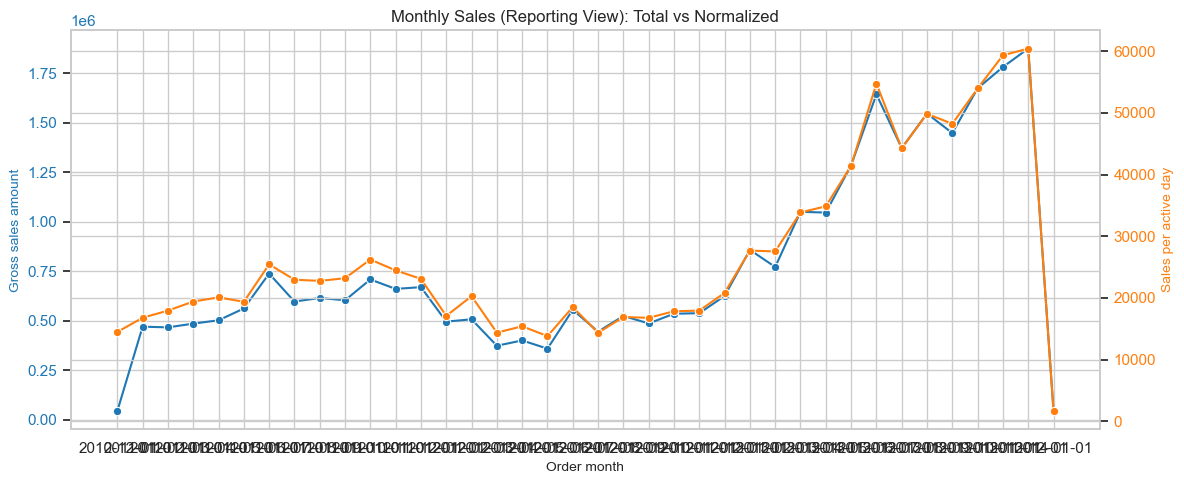

In [26]:
# Plot monthly trend from reporting layer with normalized metric to reduce partial-month bias.
if "rpt_sales_monthly_category_country" in reports:
    rpt_month = reports["rpt_sales_monthly_category_country"].copy()
    rpt_month = rpt_month.dropna(subset=["order_month"])
    rpt_month = rpt_month.groupby("order_month", as_index=False).agg(
        gross_sales_amount=("gross_sales_amount", "sum"),
        active_days=("active_days", "max"),
    )
    rpt_month = rpt_month.sort_values("order_month")
    rpt_month["sales_per_active_day"] = rpt_month["gross_sales_amount"] / rpt_month["active_days"].replace(0, np.nan)

    fig, ax1 = plt.subplots(figsize=(12, 5))
    sns.lineplot(data=rpt_month, x="order_month", y="gross_sales_amount", marker="o", ax=ax1, color="tab:blue")
    ax1.set_title("Monthly Sales (Reporting View): Total vs Normalized")
    ax1.set_xlabel("Order month")
    ax1.set_ylabel("Gross sales amount", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    sns.lineplot(data=rpt_month, x="order_month", y="sales_per_active_day", marker="o", ax=ax2, color="tab:orange")
    ax2.set_ylabel("Sales per active day", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("Reporting monthly view not loaded. Export reporting CSVs first.")